In [9]:
# === Cellule 1 : Setup pour le run IMPROVED RSNA ===
from pathlib import Path
import sys
import json
import time
import pandas as pd
from tqdm import tqdm

# Path setup
ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.medgemma_inference import medgemma_predict
from src.guardrails import apply_safety_guardrails, validate_prediction
from src.database import insert_run, init_db

# ⚠️ IMPORTANT : on charge la MÊME sélection de 50 cas que pour baseline
# pour permettre une comparaison équitable (mêmes patients, même seed)
cases_full = pd.read_csv(ROOT / "data" / "rsna_png" / "rsna_cases.csv")

import random
random.seed(42)  # ← même seed que baseline pour reproductibilité
normal = cases_full[cases_full["label"] == "normal"].sample(n=25, random_state=42)
pneumo = cases_full[cases_full["label"] == "suspected_opacity"].sample(n=25, random_state=42)
cases_df = pd.concat([normal, pneumo]).reset_index(drop=True)

print(f"✅ {len(cases_df)} cas sélectionnés (MÊME échantillon que baseline)")
print(f"   Distribution : {dict(cases_df['label'].value_counts())}")

# SQLite + output dir
db_path = ROOT / "eval" / "medical_ai_evidence.sqlite"
init_db(db_path)
out_dir = ROOT / "eval" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

print(f"⏱️ ETA : 50 cas × ~3 min = ~2h30")
print(f"🆚 Comparaison avec baseline : SQLite et CSV de baseline déjà présents")
cases_df.head()

✅ 50 cas sélectionnés (MÊME échantillon que baseline)
   Distribution : {'normal': np.int64(25), 'suspected_opacity': np.int64(25)}
⏱️ ETA : 50 cas × ~3 min = ~2h30
🆚 Comparaison avec baseline : SQLite et CSV de baseline déjà présents


,case_id,image_path,source,label,split,quality,notes,patientId
0,RSNA_014,data/rsna_png/476fd67f-33e0-47e7-b7d2-5f6e2afe...,rsna_pneumonia_2018,normal,dev,good,RSNA Pneumonia — converted from DICOM 512x512,476fd67f-33e0-47e7-b7d2-5f6e2afe4662
1,RSNA_040,data/rsna_png/a304611a-7d97-428b-a09e-26c9d11d...,rsna_pneumonia_2018,normal,dev,good,RSNA Pneumonia — converted from DICOM 512x512,a304611a-7d97-428b-a09e-26c9d11d4f51
2,RSNA_031,data/rsna_png/9bfd4fb6-ed78-41a5-9085-3282cb64...,rsna_pneumonia_2018,normal,dev,good,RSNA Pneumonia — converted from DICOM 512x512,9bfd4fb6-ed78-41a5-9085-3282cb64fc63
3,RSNA_046,data/rsna_png/e73157b2-951b-44c3-8065-87edd9d0...,rsna_pneumonia_2018,normal,dev,good,RSNA Pneumonia — converted from DICOM 512x512,e73157b2-951b-44c3-8065-87edd9d0fd6f
4,RSNA_018,data/rsna_png/fd2dbd18-2202-45da-bb4f-466c3358...,rsna_pneumonia_2018,normal,dev,good,RSNA Pneumonia — converted from DICOM 512x512,fd2dbd18-2202-45da-bb4f-466c33583179


In [2]:
# === Cellule 2 : Run IMPROVED MedGemma sur 50 cas RSNA (~2h30) ===
improved_results = []
improved_path = out_dir / "medgemma_rsna_improved_predictions.csv"

print(f"🚀 Lancement du run IMPROVED sur {len(cases_df)} cas RSNA réels...")
print(f"⏱️ ETA estimée : ~{len(cases_df) * 3:.0f} minutes ({len(cases_df) * 3 / 60:.1f} heures)")
print(f"💾 Sauvegarde incrémentale dans : {improved_path.name}\n")

for _, case in tqdm(cases_df.iterrows(), total=len(cases_df), desc="RSNA-improved"):
    image_path = ROOT / case["image_path"]

    try:
        t_start = time.perf_counter()
        pred = apply_safety_guardrails(medgemma_predict(image_path, mode="improved"))
        t_end = time.perf_counter()
        latency = int((t_end - t_start) * 1000)
        valid, errors = validate_prediction(pred)
        error_str = ""
    except Exception as e:
        pred = {"predicted_class": "uncertain", "confidence": 0.0,
                "image_quality": "poor", "visual_evidence": [],
                "justification": "ERROR", "limitations": [str(e)[:200]]}
        latency = -1
        valid = False
        error_str = str(e)[:200]

    insert_run(db_path, case["case_id"], str(image_path), pred)

    improved_results.append({
        "case_id": case["case_id"],
        "patientId": case.get("patientId", ""),
        "label": case["label"],
        "predicted_class": pred["predicted_class"],
        "confidence": pred.get("confidence", 0),
        "image_quality": pred.get("image_quality", "?"),
        "latency_ms": latency,
        "latency_min": round(latency / 60000, 2),
        "json_valid": valid,
        "error": error_str,
    })

    # 🔒 SAUVEGARDE INCRÉMENTALE après chaque cas
    pd.DataFrame(improved_results).to_csv(improved_path, index=False, encoding="utf-8")

improved_df = pd.DataFrame(improved_results)
print(f"\n✅ Run IMPROVED RSNA terminé sur {len(improved_df)} cas")
print(f"   • Latence totale : {improved_df['latency_min'].sum():.1f} min")
print(f"   • Latence moyenne : {improved_df['latency_min'].mean():.1f} min/image")
print(f"   • Erreurs : {(improved_df['error'] != '').sum()}")
print(f"   • JSON valides : {improved_df['json_valid'].sum()}/{len(improved_df)}")

improved_df.head(10)

🚀 Lancement du run IMPROVED sur 50 cas RSNA réels...
⏱️ ETA estimée : ~150 minutes (2.5 heures)
💾 Sauvegarde incrémentale dans : medgemma_rsna_improved_predictions.csv



RSNA-improved:   0%|          | 0/50 [00:00<?, ?it/s]

⏳ Chargement de google/medgemma-4b-it (1ère fois = ~4 Go à télécharger)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

✅ MedGemma chargé en 22.5 s


[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
RSNA-improved: 100%|██████████| 50/50 [2:07:50<00:00, 153.42s/it]  


✅ Run IMPROVED RSNA terminé sur 50 cas
   • Latence totale : 127.8 min
   • Latence moyenne : 2.6 min/image
   • Erreurs : 0
   • JSON valides : 50/50


,case_id,patientId,label,predicted_class,confidence,image_quality,latency_ms,latency_min,json_valid,error
0,RSNA_014,476fd67f-33e0-47e7-b7d2-5f6e2afe4662,normal,normal,0.80,good,165314,2.76,True,
1,RSNA_040,a304611a-7d97-428b-a09e-26c9d11d4f51,normal,normal,0.80,good,139150,2.32,True,
2,RSNA_031,9bfd4fb6-ed78-41a5-9085-3282cb64fc63,normal,normal,0.80,good,136415,2.27,True,
3,RSNA_046,e73157b2-951b-44c3-8065-87edd9d0fd6f,normal,suspected_opacity,0.65,good,164098,2.73,True,
4,RSNA_018,fd2dbd18-2202-45da-bb4f-466c33583179,normal,normal,0.80,good,138927,2.32,True,
5,RSNA_049,42a2589c-761a-41e0-b7a4-331214140b5d,normal,normal,0.80,good,143665,2.39,True,
6,RSNA_027,85cee2f7-9628-4c61-a51f-f7be52f5c5c9,normal,normal,0.80,good,143874,2.40,True,
7,RSNA_026,f92e409f-ade8-48a5-84db-55fa498ec3c3,normal,suspected_opacity,0.60,good,153516,2.56,True,
8,RSNA_033,5c015feb-cfd1-4ce2-9b95-eb9689c7eb0a,normal,normal,0.80,good,151827,2.53,True,
9,RSNA_020,ef6ccb09-61d9-4eba-90e6-0f35fdc02266,normal,uncertain,0.30,good,160398,2.67,True,


In [3]:
# === Cellule 3 : Métriques globales sur 50 cas RSNA IMPROVED ===
from src.metrics import accuracy, macro_f1

y_true_imp = improved_df["label"].tolist()
y_pred_imp = improved_df["predicted_class"].tolist()
valid_classes = {"normal", "suspected_opacity", "uncertain"}
hallu_imp = improved_df[~improved_df["predicted_class"].isin(valid_classes)]

metrics_imp = {
    "mode": "medgemma_improved_rsna",
    "dataset": "RSNA Pneumonia 2018",
    "n_cases": len(improved_df),
    "accuracy": round(accuracy(y_true_imp, y_pred_imp), 4),
    "macro_f1": round(macro_f1(y_true_imp, y_pred_imp), 4),
    "json_valid_rate": round(improved_df["json_valid"].mean(), 4),
    "uncertain_rate": round((improved_df["predicted_class"] == "uncertain").mean(), 4),
    "latency_min_median": round(improved_df["latency_ms"].median() / 60000, 2),
    "hallucination_count": len(hallu_imp),
}

print("📊 Métriques MedGemma IMPROVED (50 cas RSNA) :")
print(json.dumps(metrics_imp, indent=2))

print("\n🎯 Critères du brief :")
checks = [
    ("Accuracy ≥ 0.70", metrics_imp["accuracy"] >= 0.70, metrics_imp["accuracy"], 0.70),
    ("Macro-F1 ≥ 0.68", metrics_imp["macro_f1"] >= 0.68, metrics_imp["macro_f1"], 0.68),
    ("JSON valides ≥ 95%", metrics_imp["json_valid_rate"] >= 0.95, metrics_imp["json_valid_rate"], 0.95),
    ("Hallucinations = 0", metrics_imp["hallucination_count"] == 0, metrics_imp["hallucination_count"], 0),
]
for label, ok, val, target in checks:
    icon = "✅" if ok else "⚠️"
    print(f"  {icon} {label} : {val} (cible {target})")

# Sauvegarde
metrics_path = out_dir / "medgemma_rsna_improved_metrics.json"
metrics_path.write_text(json.dumps(metrics_imp, indent=2), encoding="utf-8")
print(f"\n💾 Sauvé dans : {metrics_path.name}")

📊 Métriques MedGemma IMPROVED (50 cas RSNA) :
{
  "mode": "medgemma_improved_rsna",
  "dataset": "RSNA Pneumonia 2018",
  "n_cases": 50,
  "accuracy": 0.8,
  "macro_f1": 0.5511,
  "json_valid_rate": 1.0,
  "uncertain_rate": 0.08,
  "latency_min_median": 2.54,
  "hallucination_count": 0
}

🎯 Critères du brief :
  ✅ Accuracy ≥ 0.70 : 0.8 (cible 0.7)
  ⚠️ Macro-F1 ≥ 0.68 : 0.5511 (cible 0.68)
  ✅ JSON valides ≥ 95% : 1.0 (cible 0.95)
  ✅ Hallucinations = 0 : 0 (cible 0)

💾 Sauvé dans : medgemma_rsna_improved_metrics.json


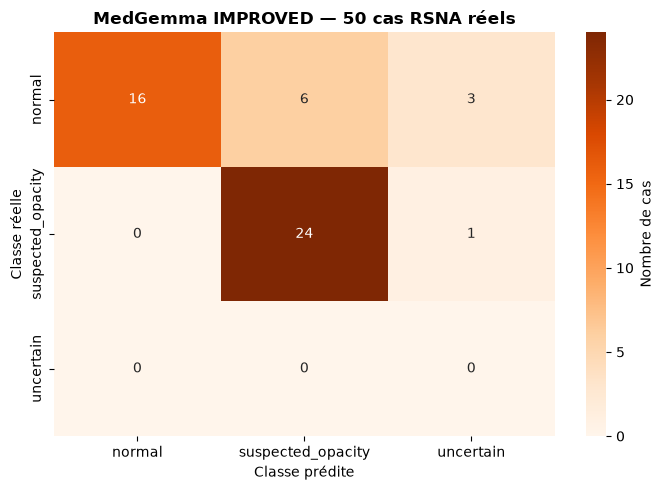


📊 Métriques détaillées par classe (improved) :


,classe,support,precision,recall,f1
0,normal,25,1.0,0.64,0.780
1,suspected_opacity,25,0.8,0.96,0.873
2,uncertain,0,0.0,0.00,0.000


In [4]:
# === Cellule 4 : Matrice de confusion + métriques par classe (improved) ===
import matplotlib.pyplot as plt
import seaborn as sns

classes = ["normal", "suspected_opacity", "uncertain"]
cm_imp = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for t, p in zip(y_true_imp, y_pred_imp):
    cm_imp.loc[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_imp, annot=True, fmt="d", cmap="Oranges", ax=ax,
            cbar_kws={"label": "Nombre de cas"})
ax.set_title("MedGemma IMPROVED — 50 cas RSNA réels", fontweight="bold")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
plt.tight_layout()
plt.show()

# Métriques par classe
print("\n📊 Métriques détaillées par classe (improved) :")
per_class_imp = []
for c in classes:
    tp = sum((t == c) and (p == c) for t, p in zip(y_true_imp, y_pred_imp))
    fp = sum((t != c) and (p == c) for t, p in zip(y_true_imp, y_pred_imp))
    fn = sum((t == c) and (p != c) for t, p in zip(y_true_imp, y_pred_imp))
    support = sum(t == c for t in y_true_imp)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    per_class_imp.append({"classe": c, "support": support,
                          "precision": round(precision, 3),
                          "recall": round(recall, 3),
                          "f1": round(f1, 3)})

per_class_imp_df = pd.DataFrame(per_class_imp)
per_class_imp_df

In [8]:
# === Cellule 5 : COMPARAISON baseline vs improved (LIVRABLE S3) ===
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recharger baseline_df depuis le CSV (si pas en mémoire)
baseline_path = out_dir / "medgemma_rsna_baseline_predictions.csv"
baseline_df = pd.read_csv(baseline_path)

# 2. Construire le DF comparatif côte à côte (sur les MÊMES cas)
comparison = baseline_df[["case_id", "label", "predicted_class", "confidence"]].rename(
    columns={"predicted_class": "baseline_class", "confidence": "baseline_conf"}
)
comparison = comparison.merge(
    improved_df[["case_id", "predicted_class", "confidence"]].rename(
        columns={"predicted_class": "improved_class", "confidence": "improved_conf"}
    ),
    on="case_id"
)

comparison["delta_conf"] = (comparison["improved_conf"] - comparison["baseline_conf"]).round(3)
comparison["class_changed"] = comparison["baseline_class"] != comparison["improved_class"]
comparison["change_type"] = comparison.apply(lambda r: (
    "FP→TP" if r["label"] == "normal" and r["baseline_class"] == "suspected_opacity" and r["improved_class"] == "normal"
    else "FP→uncertain" if r["label"] == "normal" and r["baseline_class"] == "suspected_opacity" and r["improved_class"] == "uncertain"
    else "TP→uncertain" if r["label"] == "suspected_opacity" and r["baseline_class"] == "suspected_opacity" and r["improved_class"] == "uncertain"
    else "TP→FP" if r["label"] == "normal" and r["baseline_class"] == "normal" and r["improved_class"] == "suspected_opacity"
    else "stable"
), axis=1)

print(f"📊 Total cas où la classe a changé : {comparison['class_changed'].sum()} / {len(comparison)}")
print(f"\n📋 Détail des changements :")
print(comparison["change_type"].value_counts())
print(f"\n✨ Top 10 cas qui ont changé :")
comparison[comparison["class_changed"]].head(10)

📊 Total cas où la classe a changé : 8 / 50

📋 Détail des changements :
change_type
stable          42
FP→TP            4
FP→uncertain     3
TP→uncertain     1
Name: count, dtype: int64

✨ Top 10 cas qui ont changé :


,case_id,label,baseline_class,baseline_conf,improved_class,improved_conf,delta_conf,class_changed,change_type
8,RSNA_033,normal,suspected_opacity,0.4,normal,0.8,0.4,True,FP→TP
9,RSNA_020,normal,suspected_opacity,0.6,uncertain,0.3,-0.3,True,FP→uncertain
15,RSNA_007,normal,suspected_opacity,0.6,uncertain,0.4,-0.2,True,FP→uncertain
17,RSNA_047,normal,suspected_opacity,0.4,normal,0.8,0.4,True,FP→TP
19,RSNA_016,normal,suspected_opacity,0.6,uncertain,0.4,-0.2,True,FP→uncertain
23,RSNA_035,normal,suspected_opacity,0.4,normal,0.8,0.4,True,FP→TP
24,RSNA_032,normal,suspected_opacity,0.6,normal,0.8,0.2,True,FP→TP
37,RSNA_088,suspected_opacity,suspected_opacity,0.6,uncertain,0.4,-0.2,True,TP→uncertain


In [11]:
# === Cellule 6 (FIXED) : Tableau de synthèse baseline vs improved ===
# Rechargement des métriques depuis les JSON sauvegardés
metrics_path_base = out_dir / "medgemma_rsna_baseline_metrics.json"
metrics_path_imp = out_dir / "medgemma_rsna_improved_metrics.json"

metrics = json.loads(metrics_path_base.read_text(encoding="utf-8"))
metrics_imp = json.loads(metrics_path_imp.read_text(encoding="utf-8"))

print(f"✅ Métriques baseline rechargées : {metrics_path_base.name}")
print(f"✅ Métriques improved rechargées : {metrics_path_imp.name}")

# Construction du tableau de synthèse
comparison_summary = pd.DataFrame([
    {"métrique": "Accuracy",
     "baseline": metrics["accuracy"],
     "improved": metrics_imp["accuracy"]},
    {"métrique": "Macro-F1",
     "baseline": metrics["macro_f1"],
     "improved": metrics_imp["macro_f1"]},
    {"métrique": "JSON valides",
     "baseline": metrics["json_valid_rate"],
     "improved": metrics_imp["json_valid_rate"]},
    {"métrique": "Taux uncertain",
     "baseline": metrics["uncertain_rate"],
     "improved": metrics_imp["uncertain_rate"]},
    {"métrique": "Latence médiane (min)",
     "baseline": metrics["latency_min_median"],
     "improved": metrics_imp["latency_min_median"]},
    {"métrique": "Hallucinations",
     "baseline": metrics["hallucination_count"],
     "improved": metrics_imp["hallucination_count"]},
])
comparison_summary["delta"] = (comparison_summary["improved"] - comparison_summary["baseline"]).round(4)

print("\n📋 Tableau de comparaison (LIVRABLE S3) :")
comparison_summary

✅ Métriques baseline rechargées : medgemma_rsna_baseline_metrics.json
✅ Métriques improved rechargées : medgemma_rsna_improved_metrics.json

📋 Tableau de comparaison (LIVRABLE S3) :


,métrique,baseline,improved,delta
0,Accuracy,0.7400,0.8000,0.0600
1,Macro-F1,0.4808,0.5511,0.0703
2,JSON valides,1.0000,1.0000,0.0000
3,Taux uncertain,0.0000,0.0800,0.0800
4,Latence médiane (min),2.7700,2.5400,-0.2300
5,Hallucinations,0.0000,0.0000,0.0000


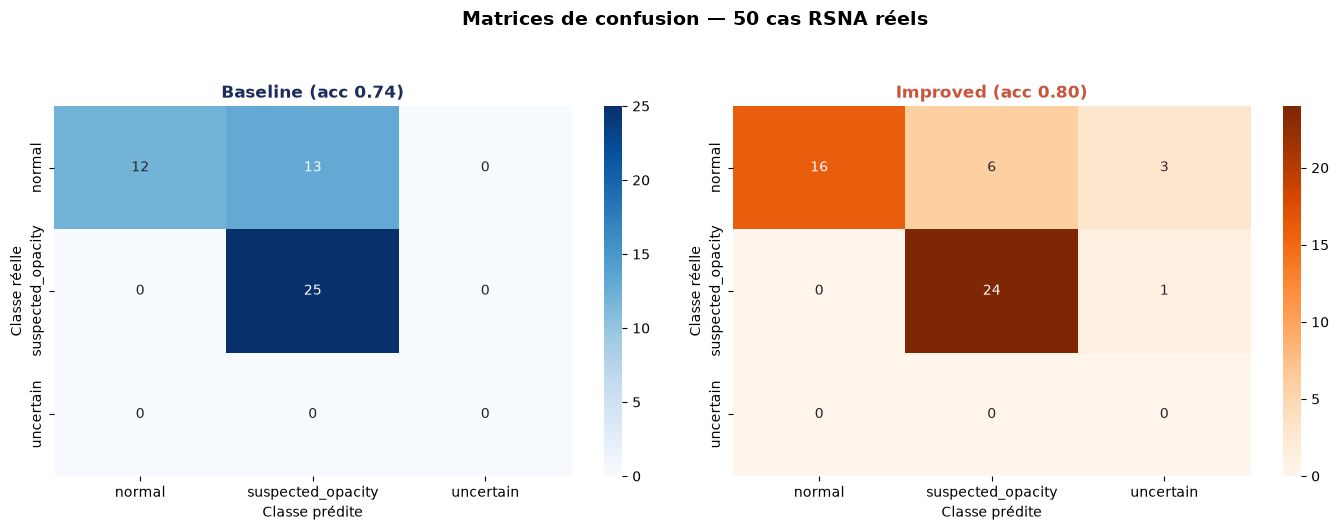

In [12]:
# === Cellule 7 : 2 matrices de confusion côte à côte ===
classes = ["normal", "suspected_opacity", "uncertain"]

cm_base = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for t, p in zip(baseline_df["label"], baseline_df["predicted_class"]):
    cm_base.loc[t, p] += 1

cm_imp = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for t, p in zip(improved_df["label"], improved_df["predicted_class"]):
    cm_imp.loc[t, p] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Baseline (acc 0.74)", fontweight="bold", color="#1B2D5B")
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")

sns.heatmap(cm_imp, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("Improved (acc 0.80)", fontweight="bold", color="#C8553D")
axes[1].set_xlabel("Classe prédite")
axes[1].set_ylabel("Classe réelle")

fig.suptitle("Matrices de confusion — 50 cas RSNA réels", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


In [13]:
# === Cellule 8 : Sauvegarde des artefacts S3 ===
comparison_path = out_dir / "medgemma_rsna_baseline_vs_improved.csv"
comparison.to_csv(comparison_path, index=False, encoding="utf-8")
print(f"✅ Comparaison écrite : {comparison_path.name}")

comparison_summary_path = out_dir / "medgemma_rsna_comparison_summary.csv"
comparison_summary.to_csv(comparison_summary_path, index=False, encoding="utf-8")
print(f"✅ Synthèse écrite : {comparison_summary_path.name}")

comparison_metrics = {
    "baseline": metrics,
    "improved": metrics_imp,
    "deltas": {
        "accuracy": round(metrics_imp["accuracy"] - metrics["accuracy"], 4),
        "macro_f1": round(metrics_imp["macro_f1"] - metrics["macro_f1"], 4),
        "uncertain_rate": round(metrics_imp["uncertain_rate"] - metrics["uncertain_rate"], 4),
    },
    "n_class_changed": int(comparison["class_changed"].sum()),
    "change_types": comparison["change_type"].value_counts().to_dict(),
}
comparison_json_path = out_dir / "medgemma_rsna_comparison_metrics.json"
comparison_json_path.write_text(json.dumps(comparison_metrics, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"✅ Métriques de comparaison écrites : {comparison_json_path.name}")

print(f"\n📦 Récapitulatif des artefacts S3 :")
for p in [comparison_path, comparison_summary_path, comparison_json_path]:
    print(f"  • {p.name} ({p.stat().st_size} octets)")
    

✅ Comparaison écrite : medgemma_rsna_baseline_vs_improved.csv
✅ Synthèse écrite : medgemma_rsna_comparison_summary.csv
✅ Métriques de comparaison écrites : medgemma_rsna_comparison_metrics.json

📦 Récapitulatif des artefacts S3 :
  • medgemma_rsna_baseline_vs_improved.csv (4029 octets)
  • medgemma_rsna_comparison_summary.csv (214 octets)
  • medgemma_rsna_comparison_metrics.json (819 octets)
